# Enhanced ML Pipeline: Data Processing, Visualization, Model Comparison & Azure Deployment

This notebook covers:
1. Loading and exploring the dataset
2. Data preprocessing and feature engineering
3. Comprehensive visualizations
4. Dimensionality reduction (PCA)
5. Training and comparing 3 different models
6. Selecting the best model
7. Deploying the best model to Azure Container Instance (ACI)

## Prerequisites
- Azure subscription
- Azure Machine Learning workspace
- Required Python packages (installed below)

## Step 1: Install Required Packages

In [ ]:
# Install required packages
!pip install azureml-core azureml-sdk scikit-learn pandas numpy joblib matplotlib seaborn plotly

## Step 2: Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Data processing
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Models
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Utilities
import joblib
import json
import time

# Azure ML imports
from azureml.core import Workspace, Model, Environment
from azureml.core.webservice import AciWebservice, Webservice
from azureml.core.model import InferenceConfig
from azureml.core.conda_dependencies import CondaDependencies

# Set plotting style
sns.set_palette("husl")

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## Step 3: Load Dataset

In [4]:
# Load dataset
diabetes = load_diabetes()
X = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y = pd.Series(diabetes.target, name='target')

print(f"Dataset shape: {X.shape}")
print(f"\nFeatures: {list(X.columns)}")
print(f"\nTarget variable (disease progression): min={y.min():.1f}, max={y.max():.1f}, mean={y.mean():.1f}")

Dataset shape: (442, 10)

Features: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

Target variable (disease progression): min=25.0, max=346.0, mean=152.1


## Step 4: Exploratory Data Analysis (EDA)

In [5]:
# Basic statistics
print("Dataset Statistics:")
print("=" * 80)
display(X.describe())

# Check for missing values
print("\nMissing Values:")
print(X.isnull().sum())

# Data info
print("\nDataset Info:")
X.info()

Dataset Statistics:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02
mean,-3.639623e-16,1.309912e-16,-8.013951e-16,1.289818e-16,-9.042540e-17,1.301121e-16,-4.563971e-16,3.863174e-16,-3.848103e-16,-3.398488e-16
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123996e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260974e-01,-1.377672e-01
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665645e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324879e-02,-3.317903e-02
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670611e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947634e-03,-1.077698e-03
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564384e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243323e-02,2.791705e-02
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320442e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335990e-01,1.356118e-01



Missing Values:
age    0
sex    0
bmi    0
bp     0
s1     0
s2     0
s3     0
s4     0
s5     0
s6     0
dtype: int64

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
dtypes: float64(10)
memory usage: 34.7 KB


## Step 5: Data Visualization

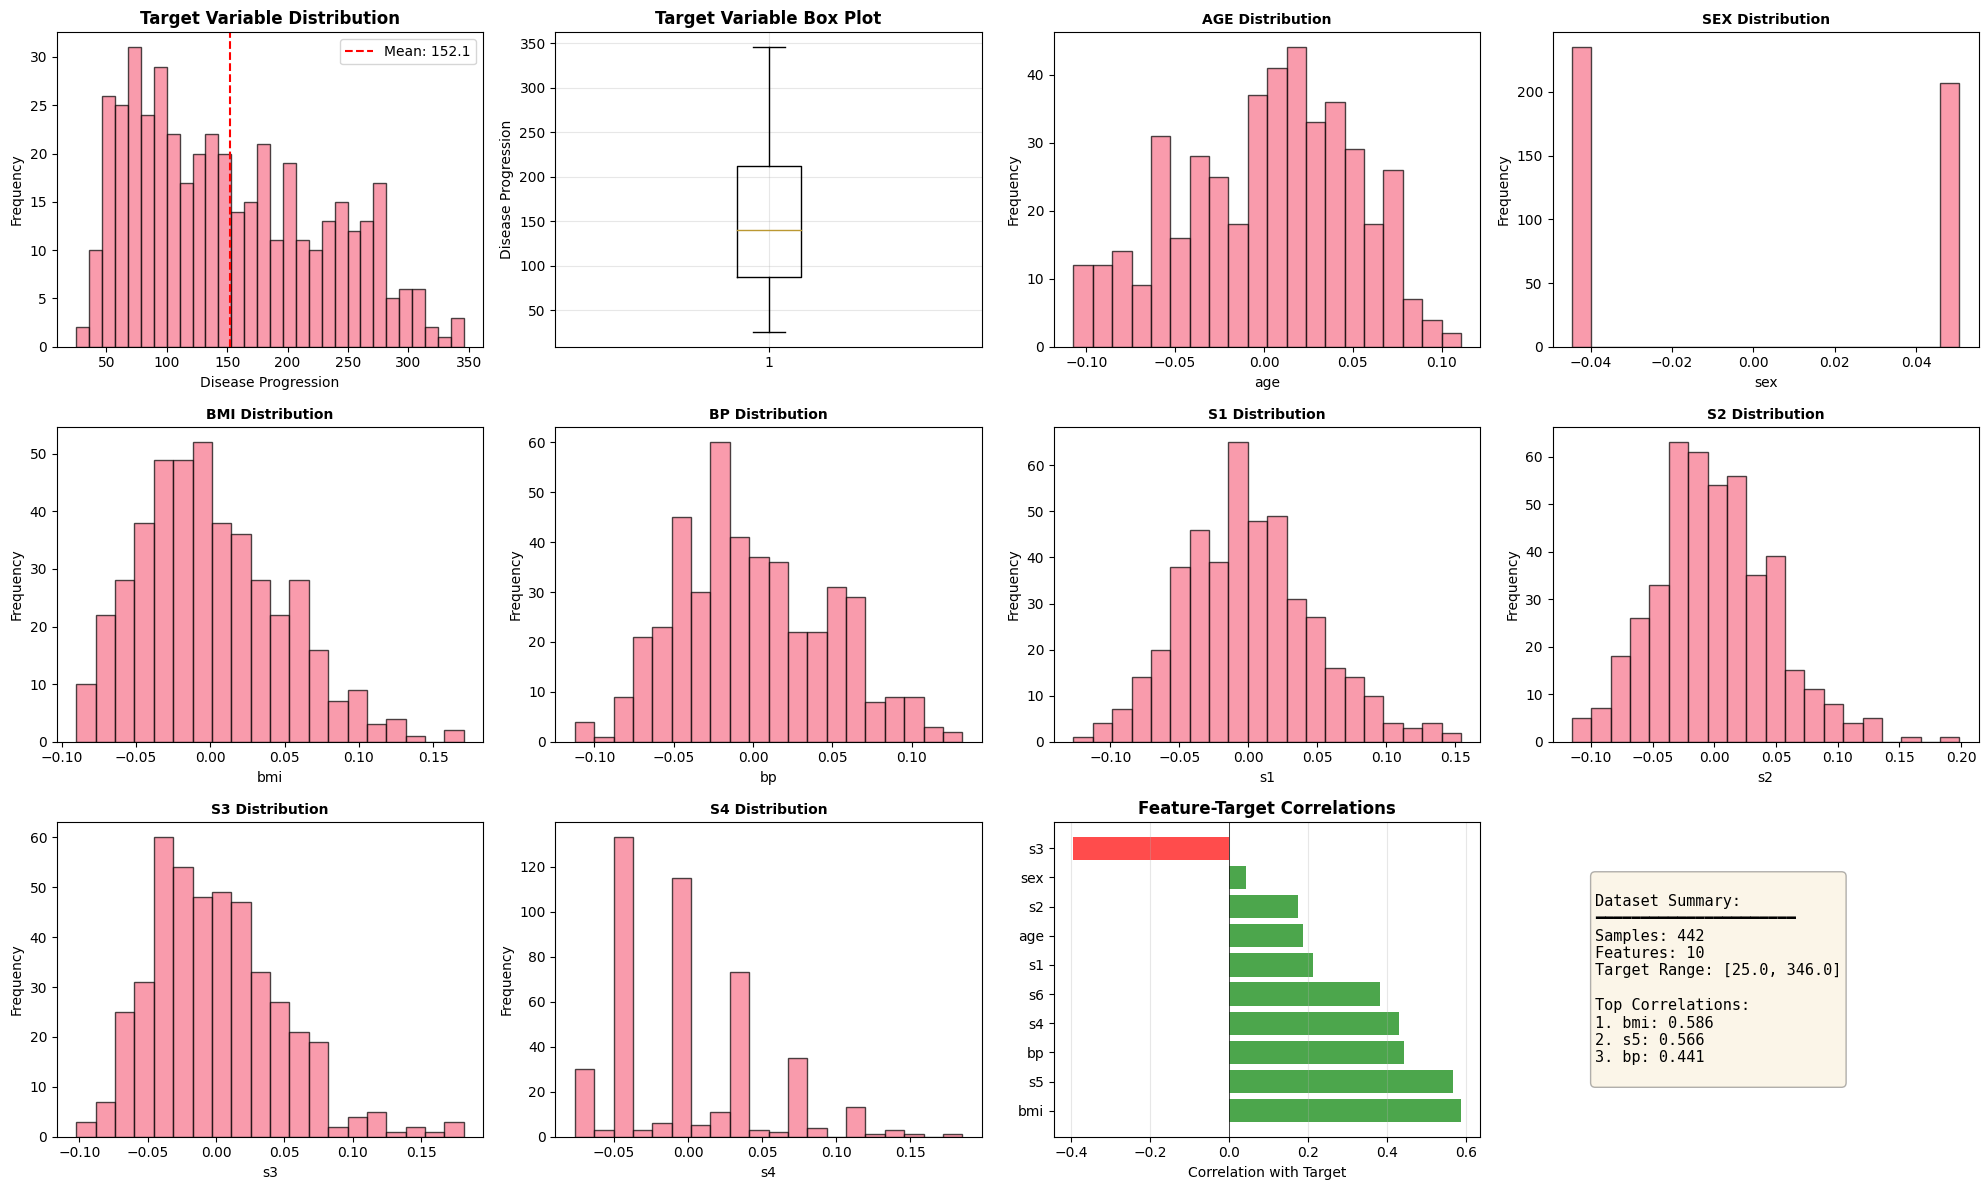


✅ Visualizations saved as 'eda_visualizations.png'


In [6]:
# Create comprehensive visualizations
fig = plt.figure(figsize=(20, 12))

# 1. Target distribution
plt.subplot(3, 4, 1)
plt.hist(y, bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Disease Progression')
plt.ylabel('Frequency')
plt.title('Target Variable Distribution', fontweight='bold')
plt.axvline(y.mean(), color='red', linestyle='--', label=f'Mean: {y.mean():.1f}')
plt.legend()

# 2. Box plot of target
plt.subplot(3, 4, 2)
plt.boxplot(y, vert=True)
plt.ylabel('Disease Progression')
plt.title('Target Variable Box Plot', fontweight='bold')
plt.grid(True, alpha=0.3)

# 3-10. Feature distributions
for idx, col in enumerate(X.columns[:8], start=3):
    plt.subplot(3, 4, idx)
    plt.hist(X[col], bins=20, edgecolor='black', alpha=0.7)
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.title(f'{col.upper()} Distribution', fontsize=10, fontweight='bold')

# 11. Correlation with target
plt.subplot(3, 4, 11)
correlations = X.corrwith(y).sort_values(ascending=False)
colors = ['green' if x > 0 else 'red' for x in correlations]
plt.barh(range(len(correlations)), correlations.values, color=colors, alpha=0.7)
plt.yticks(range(len(correlations)), correlations.index)
plt.xlabel('Correlation with Target')
plt.title('Feature-Target Correlations', fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.grid(True, alpha=0.3, axis='x')

# 12. Sample of data
plt.subplot(3, 4, 12)
plt.axis('off')
summary_text = f"""
Dataset Summary:
━━━━━━━━━━━━━━━━━━━━━━
Samples: {len(X)}
Features: {X.shape[1]}
Target Range: [{y.min():.1f}, {y.max():.1f}]

Top Correlations:
1. {correlations.index[0]}: {correlations.values[0]:.3f}
2. {correlations.index[1]}: {correlations.values[1]:.3f}
3. {correlations.index[2]}: {correlations.values[2]:.3f}
"""
plt.text(0.1, 0.5, summary_text, fontsize=11, verticalalignment='center',
         family='monospace', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.tight_layout()
plt.savefig('eda_visualizations.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Visualizations saved as 'eda_visualizations.png'")

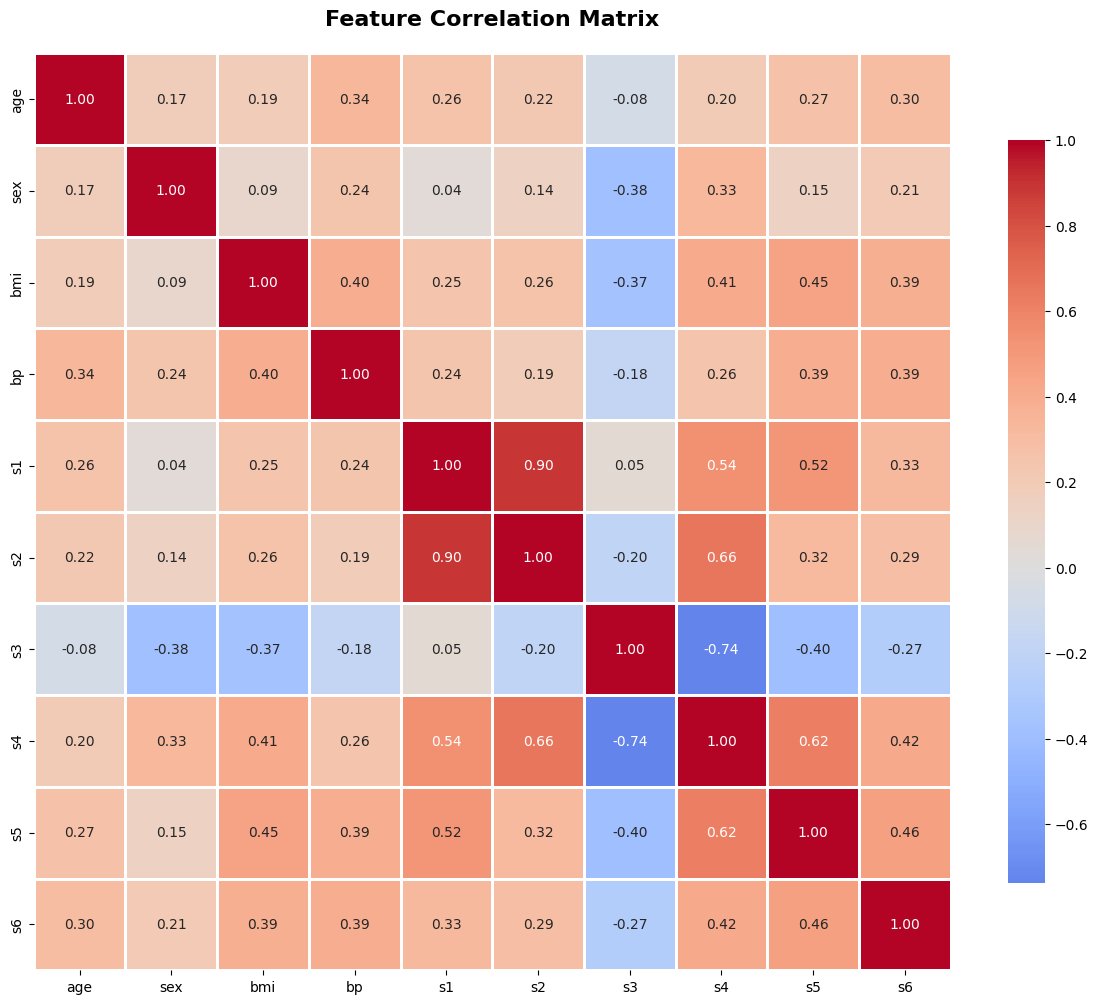

✅ Correlation matrix saved as 'correlation_matrix.png'


In [7]:
# Correlation heatmap
plt.figure(figsize=(12, 10))
correlation_matrix = X.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Correlation matrix saved as 'correlation_matrix.png'")

Creating pairplot for top 4 features: ['bmi', 's5', 'bp', 's4']


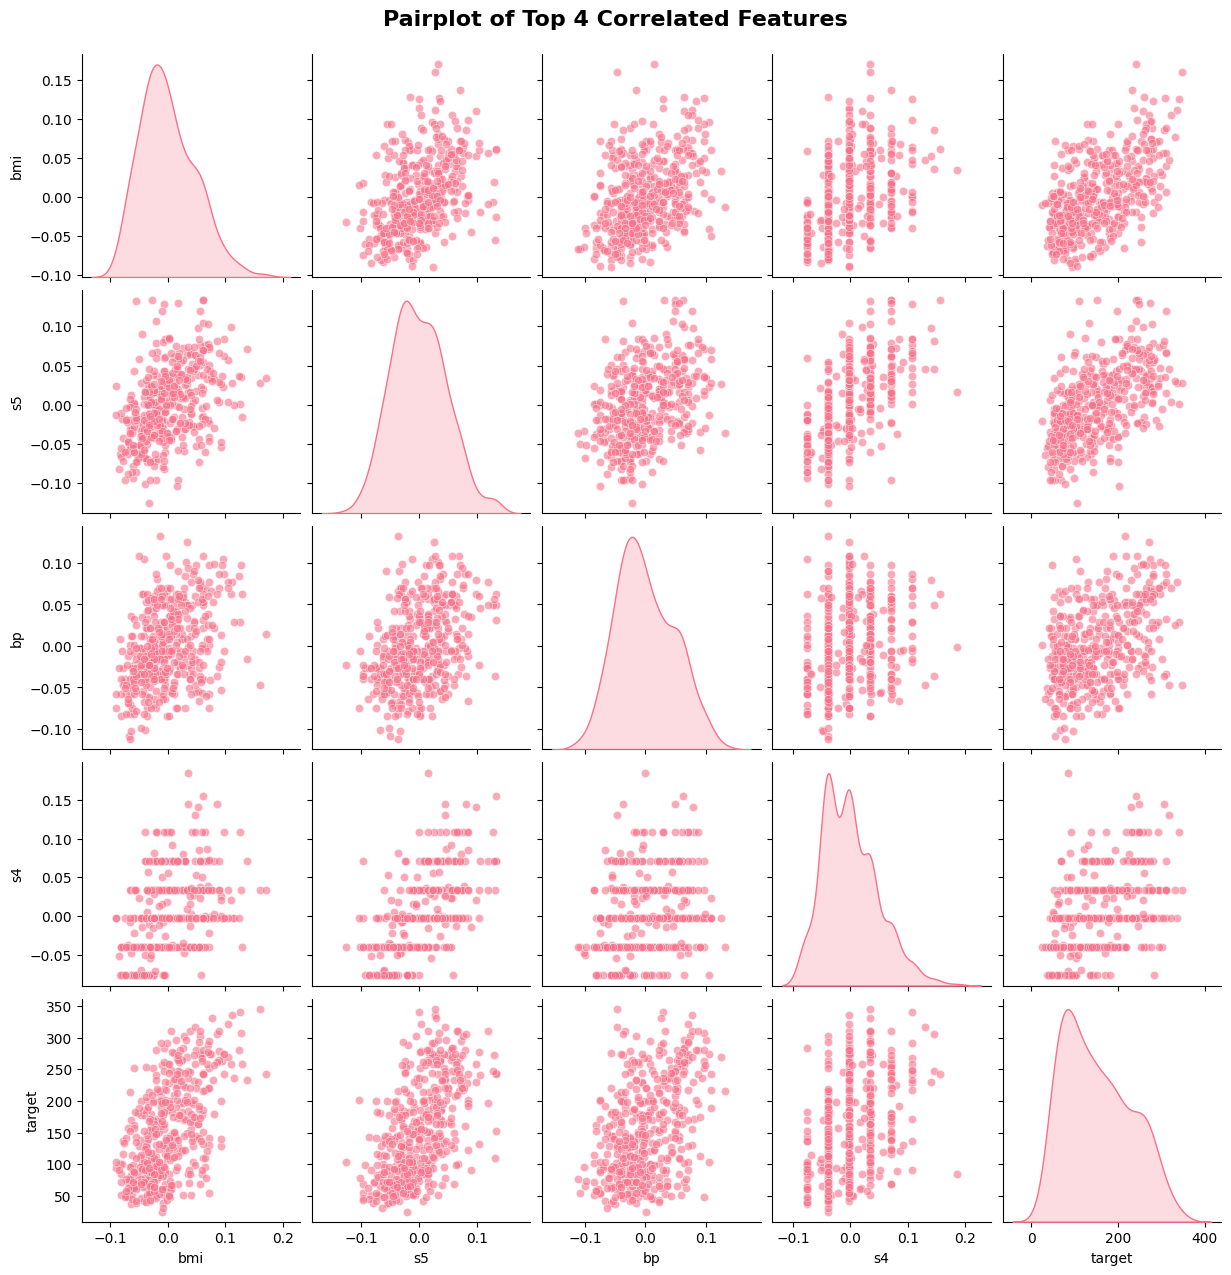

✅ Pairplot saved as 'pairplot.png'


In [8]:
# Pairplot for top 4 correlated features with target
top_features = correlations.abs().sort_values(ascending=False).head(4).index.tolist()
plot_data = X[top_features].copy()
plot_data['target'] = y

print(f"Creating pairplot for top 4 features: {top_features}")
pairplot = sns.pairplot(plot_data, diag_kind='kde', plot_kws={'alpha': 0.6})
pairplot.fig.suptitle('Pairplot of Top 4 Correlated Features', y=1.02, fontsize=16, fontweight='bold')
plt.savefig('pairplot.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Pairplot saved as 'pairplot.png'")

## Step 6: Data Preprocessing

In [9]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"\nTraining set target - Mean: {y_train.mean():.2f}, Std: {y_train.std():.2f}")
print(f"Test set target - Mean: {y_test.mean():.2f}, Std: {y_test.std():.2f}")

Training set size: 353 samples
Test set size: 89 samples

Training set target - Mean: 153.74, Std: 78.06
Test set target - Mean: 145.78, Std: 73.20


In [10]:
# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrames for easier handling
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

print("✅ Features standardized (mean=0, std=1)")
print(f"\nScaled training set statistics:")
print(f"Mean: {X_train_scaled.mean().mean():.6f}")
print(f"Std: {X_train_scaled.std().mean():.6f}")

✅ Features standardized (mean=0, std=1)

Scaled training set statistics:
Mean: -0.000000
Std: 1.001419


## Step 7: Dimensionality Reduction with PCA

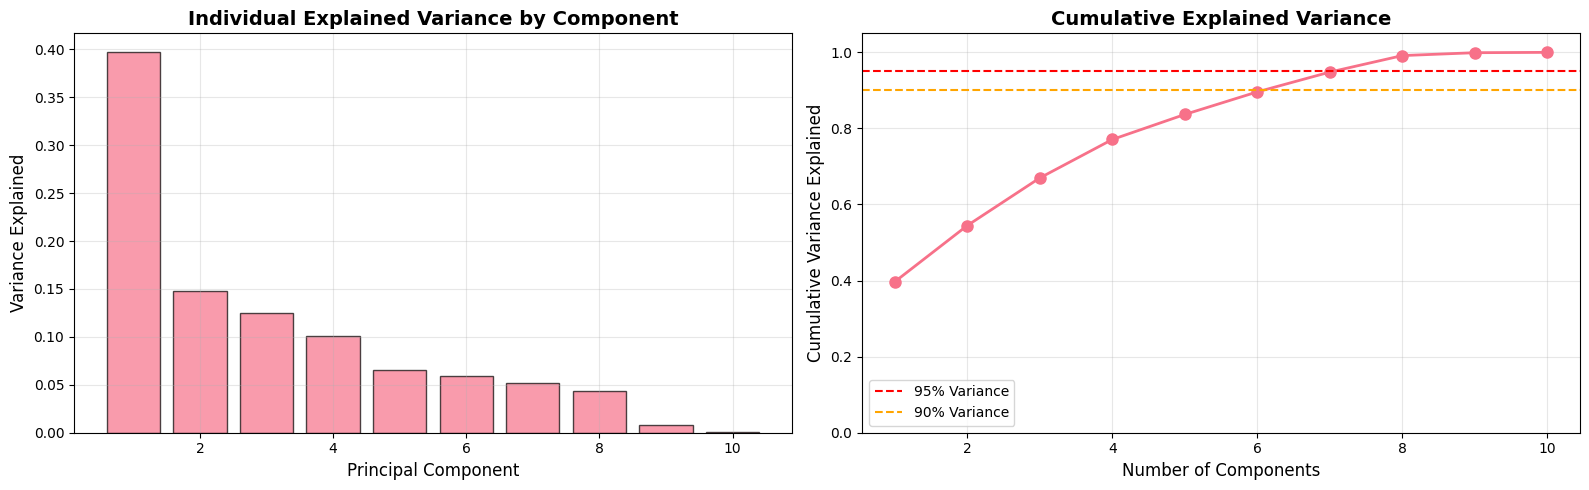


PCA Analysis Results:
Components needed for 90% variance: 7
Components needed for 95% variance: 8

Variance explained by each component:
  PC1: 39.69%
  PC2: 14.78%
  PC3: 12.52%
  PC4: 10.11%
  PC5: 6.58%

✅ PCA analysis saved as 'pca_analysis.png'


In [11]:
# Perform PCA to understand variance
pca_full = PCA()
pca_full.fit(X_train_scaled)

# Calculate cumulative explained variance
cumsum_variance = np.cumsum(pca_full.explained_variance_ratio_)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Individual variance explained
axes[0].bar(range(1, len(pca_full.explained_variance_ratio_) + 1),
            pca_full.explained_variance_ratio_, alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Principal Component', fontsize=12)
axes[0].set_ylabel('Variance Explained', fontsize=12)
axes[0].set_title('Individual Explained Variance by Component', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Cumulative variance explained
axes[1].plot(range(1, len(cumsum_variance) + 1), cumsum_variance, 
             marker='o', linestyle='-', linewidth=2, markersize=8)
axes[1].axhline(y=0.95, color='r', linestyle='--', label='95% Variance')
axes[1].axhline(y=0.90, color='orange', linestyle='--', label='90% Variance')
axes[1].set_xlabel('Number of Components', fontsize=12)
axes[1].set_ylabel('Cumulative Variance Explained', fontsize=12)
axes[1].set_title('Cumulative Explained Variance', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0, 1.05])

plt.tight_layout()
plt.savefig('pca_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Determine optimal number of components
n_components_95 = np.argmax(cumsum_variance >= 0.95) + 1
n_components_90 = np.argmax(cumsum_variance >= 0.90) + 1

print(f"\nPCA Analysis Results:")
print("=" * 60)
print(f"Components needed for 90% variance: {n_components_90}")
print(f"Components needed for 95% variance: {n_components_95}")
print(f"\nVariance explained by each component:")
for i, var in enumerate(pca_full.explained_variance_ratio_[:5], 1):
    print(f"  PC{i}: {var*100:.2f}%")

print("\n✅ PCA analysis saved as 'pca_analysis.png'")

In [12]:
# Apply PCA transformation (using 95% variance threshold)
pca = PCA(n_components=n_components_95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Original features: {X_train_scaled.shape[1]}")
print(f"Reduced features (PCA): {X_train_pca.shape[1]}")
print(f"Variance preserved: {cumsum_variance[n_components_95-1]*100:.2f}%")

Original features: 10
Reduced features (PCA): 8
Variance preserved: 99.15%


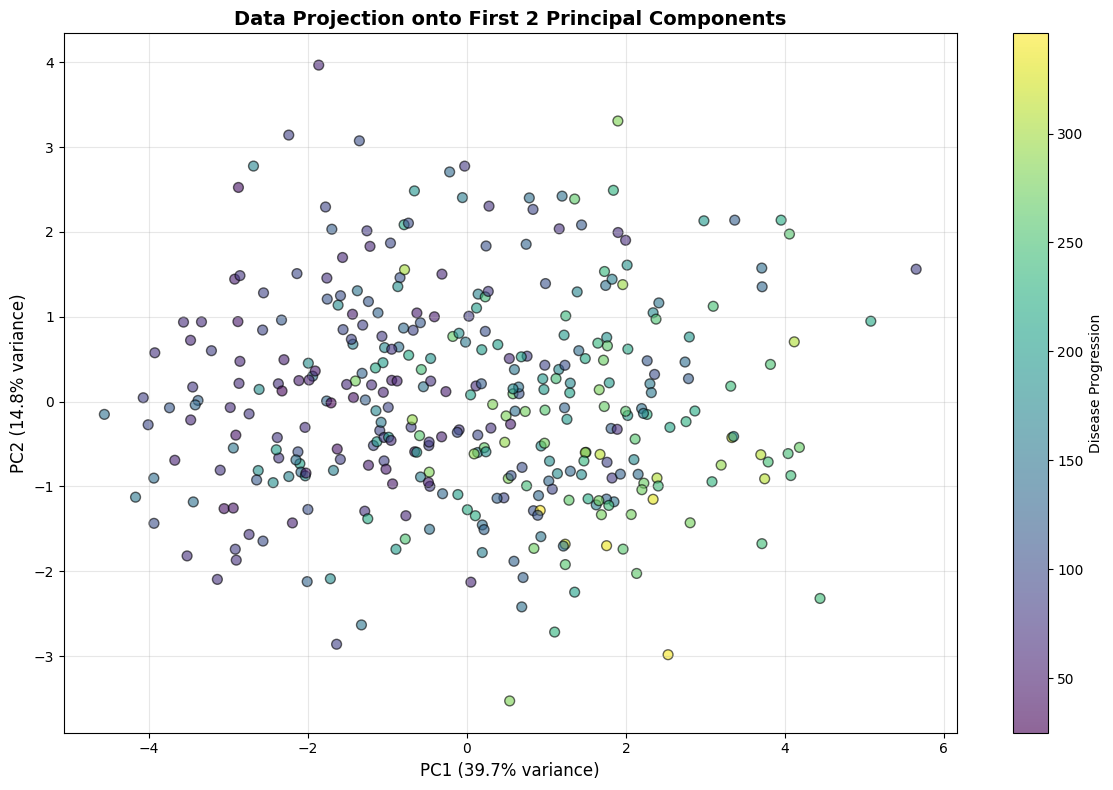

✅ 2D PCA projection saved as 'pca_2d_projection.png'


In [13]:
# Visualize data in 2D PCA space
pca_2d = PCA(n_components=2)
X_train_2d = pca_2d.fit_transform(X_train_scaled)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_train_2d[:, 0], X_train_2d[:, 1], 
                     c=y_train, cmap='viridis', alpha=0.6, s=50, edgecolors='black')
plt.colorbar(scatter, label='Disease Progression')
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=12)
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=12)
plt.title('Data Projection onto First 2 Principal Components', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('pca_2d_projection.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ 2D PCA projection saved as 'pca_2d_projection.png'")

## Step 8: Feature Engineering (Optional Enhancement)

In [14]:
# Create interaction features between highly correlated features
X_train_enhanced = X_train_scaled.copy()
X_test_enhanced = X_test_scaled.copy()

# Add polynomial features for top correlated features
for i, feat in enumerate(top_features[:3]):
    X_train_enhanced[f'{feat}_squared'] = X_train_scaled[feat] ** 2
    X_test_enhanced[f'{feat}_squared'] = X_test_scaled[feat] ** 2

# Add interaction terms
if len(top_features) >= 2:
    X_train_enhanced['interaction_1'] = X_train_scaled[top_features[0]] * X_train_scaled[top_features[1]]
    X_test_enhanced['interaction_1'] = X_test_scaled[top_features[0]] * X_test_scaled[top_features[1]]

print(f"Original features: {X_train_scaled.shape[1]}")
print(f"Enhanced features: {X_train_enhanced.shape[1]}")
print(f"New features added: {X_train_enhanced.shape[1] - X_train_scaled.shape[1]}")

Original features: 10
Enhanced features: 14
New features added: 4


## Step 9: Train and Compare Multiple Models

We'll train and compare three different models:
1. **Random Forest Regressor** - Ensemble method using decision trees
2. **Gradient Boosting Regressor** - Sequential ensemble method
3. **Ridge Regression** - Linear model with L2 regularization

In [15]:
# Dictionary to store results
results = {
    'model_name': [],
    'train_time': [],
    'train_r2': [],
    'test_r2': [],
    'train_rmse': [],
    'test_rmse': [],
    'test_mae': [],
    'cv_score_mean': [],
    'cv_score_std': [],
    'model_object': []
}

# We'll use the enhanced features for training
X_train_final = X_train_enhanced
X_test_final = X_test_enhanced

In [19]:
# Model 2: Gradient Boosting Regressor
print("Training Model 2: Gradient Boosting Regressor")
print("=" * 60)

start_time = time.time()
gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    min_samples_split=5,
    min_samples_leaf=2,
    subsample=0.8,
    random_state=42
)
gb_model.fit(X_train_final, y_train)
train_time = time.time() - start_time

# Predictions
y_train_pred_gb = gb_model.predict(X_train_final)
y_test_pred_gb = gb_model.predict(X_test_final)

# Metrics
train_r2_gb = r2_score(y_train, y_train_pred_gb)
test_r2_gb = r2_score(y_test, y_test_pred_gb)
train_rmse_gb = np.sqrt(mean_squared_error(y_train, y_train_pred_gb))
test_rmse_gb = np.sqrt(mean_squared_error(y_test, y_test_pred_gb))
test_mae_gb = mean_absolute_error(y_test, y_test_pred_gb)

# Cross-validation
cv_scores_gb = cross_val_score(gb_model, X_train_final, y_train, cv=5, 
                                scoring='r2')

# Store results
results['model_name'].append('Gradient Boosting')
results['train_time'].append(train_time)
results['train_r2'].append(train_r2_gb)
results['test_r2'].append(test_r2_gb)
results['train_rmse'].append(train_rmse_gb)
results['test_rmse'].append(test_rmse_gb)
results['test_mae'].append(test_mae_gb)
results['cv_score_mean'].append(cv_scores_gb.mean())
results['cv_score_std'].append(cv_scores_gb.std())
results['model_object'].append(gb_model)

print(f"✅ Training Time: {train_time:.3f}s")
print(f"Train R²: {train_r2_gb:.4f}")
print(f"Test R²: {test_r2_gb:.4f}")
print(f"Test RMSE: {test_rmse_gb:.4f}")
print(f"Test MAE: {test_mae_gb:.4f}")
print(f"CV R² Score: {cv_scores_gb.mean():.4f} (+/- {cv_scores_gb.std():.4f})")
print()

Training Model 2: Gradient Boosting Regressor
✅ Training Time: 0.246s
Train R²: 0.9995
Test R²: 0.3102
Test RMSE: 60.4538
Test MAE: 48.6198
CV R² Score: 0.3080 (+/- 0.1985)



In [20]:
# Model 3: Ridge Regression
print("Training Model 3: Ridge Regression")
print("=" * 60)

start_time = time.time()
ridge_model = Ridge(
    alpha=1.0,
    random_state=42
)
ridge_model.fit(X_train_final, y_train)
train_time = time.time() - start_time

# Predictions
y_train_pred_ridge = ridge_model.predict(X_train_final)
y_test_pred_ridge = ridge_model.predict(X_test_final)

# Metrics
train_r2_ridge = r2_score(y_train, y_train_pred_ridge)
test_r2_ridge = r2_score(y_test, y_test_pred_ridge)
train_rmse_ridge = np.sqrt(mean_squared_error(y_train, y_train_pred_ridge))
test_rmse_ridge = np.sqrt(mean_squared_error(y_test, y_test_pred_ridge))
test_mae_ridge = mean_absolute_error(y_test, y_test_pred_ridge)

# Cross-validation
cv_scores_ridge = cross_val_score(ridge_model, X_train_final, y_train, cv=5, 
                                  scoring='r2')

# Store results
results['model_name'].append('Ridge Regression')
results['train_time'].append(train_time)
results['train_r2'].append(train_r2_ridge)
results['test_r2'].append(test_r2_ridge)
results['train_rmse'].append(train_rmse_ridge)
results['test_rmse'].append(test_rmse_ridge)
results['test_mae'].append(test_mae_ridge)
results['cv_score_mean'].append(cv_scores_ridge.mean())
results['cv_score_std'].append(cv_scores_ridge.std())
results['model_object'].append(ridge_model)

print(f"✅ Training Time: {train_time:.3f}s")
print(f"Train R²: {train_r2_ridge:.4f}")
print(f"Test R²: {test_r2_ridge:.4f}")
print(f"Test RMSE: {test_rmse_ridge:.4f}")
print(f"Test MAE: {test_mae_ridge:.4f}")
print(f"CV R² Score: {cv_scores_ridge.mean():.4f} (+/- {cv_scores_ridge.std():.4f})")
print()

Training Model 3: Ridge Regression
✅ Training Time: 0.003s
Train R²: 0.5339
Test R²: 0.4618
Test RMSE: 53.3967
Test MAE: 42.5830
CV R² Score: 0.4458 (+/- 0.1447)



## Step 10: Compare Model Performance

In [21]:
# Create results DataFrame
results_df = pd.DataFrame({
    'Model': results['model_name'],
    'Train Time (s)': results['train_time'],
    'Train R²': results['train_r2'],
    'Test R²': results['test_r2'],
    'Train RMSE': results['train_rmse'],
    'Test RMSE': results['test_rmse'],
    'Test MAE': results['test_mae'],
    'CV R² Mean': results['cv_score_mean'],
    'CV R² Std': results['cv_score_std']
})

print("\n" + "="*100)
print("MODEL COMPARISON RESULTS")
print("="*100)
display(results_df.style.highlight_max(subset=['Test R²', 'CV R² Mean'], color='lightgreen')
                       .highlight_min(subset=['Test RMSE', 'Test MAE', 'Train Time (s)'], color='lightgreen')
                       .format({
                           'Train Time (s)': '{:.3f}',
                           'Train R²': '{:.4f}',
                           'Test R²': '{:.4f}',
                           'Train RMSE': '{:.4f}',
                           'Test RMSE': '{:.4f}',
                           'Test MAE': '{:.4f}',
                           'CV R² Mean': '{:.4f}',
                           'CV R² Std': '{:.4f}'
                       }))


MODEL COMPARISON RESULTS


,Model,Train Time (s),Train R²,Test R²,Train RMSE,Test RMSE,Test MAE,CV R² Mean,CV R² Std
0,Gradient Boosting,0.246,0.9995,0.3102,1.7191,60.4538,48.6198,0.3080,0.1985
1,Ridge Regression,0.003,0.5339,0.4618,53.2179,53.3967,42.5830,0.4458,0.1447


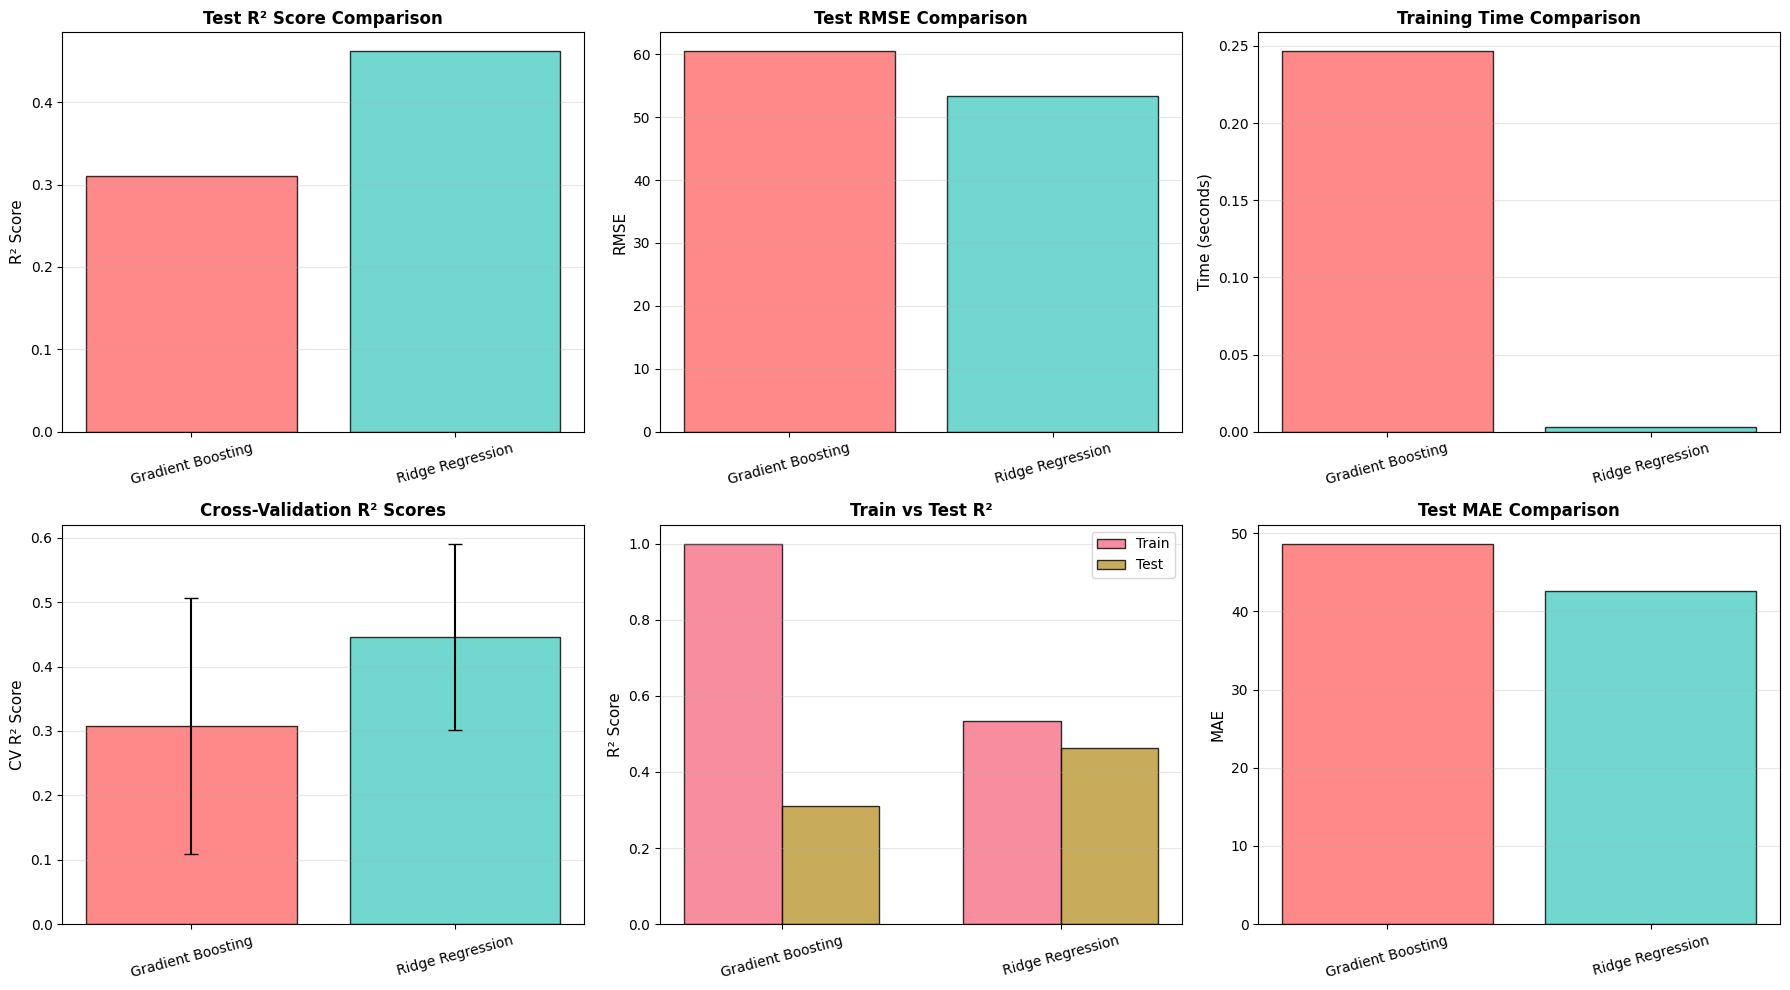

✅ Model comparison visualization saved as 'model_comparison.png'


In [22]:
# Visualize model comparison
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Test R² comparison
axes[0, 0].bar(results_df['Model'], results_df['Test R²'], color=['#FF6B6B', '#4ECDC4', '#45B7D1'], alpha=0.8, edgecolor='black')
axes[0, 0].set_ylabel('R² Score', fontsize=11)
axes[0, 0].set_title('Test R² Score Comparison', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3, axis='y')
axes[0, 0].tick_params(axis='x', rotation=15)

# 2. Test RMSE comparison
axes[0, 1].bar(results_df['Model'], results_df['Test RMSE'], color=['#FF6B6B', '#4ECDC4', '#45B7D1'], alpha=0.8, edgecolor='black')
axes[0, 1].set_ylabel('RMSE', fontsize=11)
axes[0, 1].set_title('Test RMSE Comparison', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3, axis='y')
axes[0, 1].tick_params(axis='x', rotation=15)

# 3. Training time comparison
axes[0, 2].bar(results_df['Model'], results_df['Train Time (s)'], color=['#FF6B6B', '#4ECDC4', '#45B7D1'], alpha=0.8, edgecolor='black')
axes[0, 2].set_ylabel('Time (seconds)', fontsize=11)
axes[0, 2].set_title('Training Time Comparison', fontsize=12, fontweight='bold')
axes[0, 2].grid(True, alpha=0.3, axis='y')
axes[0, 2].tick_params(axis='x', rotation=15)

# 4. Cross-validation scores
x_pos = np.arange(len(results_df))
axes[1, 0].bar(x_pos, results_df['CV R² Mean'], yerr=results_df['CV R² Std'], 
               color=['#FF6B6B', '#4ECDC4', '#45B7D1'], alpha=0.8, edgecolor='black', capsize=5)
axes[1, 0].set_xticks(x_pos)
axes[1, 0].set_xticklabels(results_df['Model'], rotation=15)
axes[1, 0].set_ylabel('CV R² Score', fontsize=11)
axes[1, 0].set_title('Cross-Validation R² Scores', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 5. Train vs Test R² for each model
x = np.arange(len(results_df))
width = 0.35
axes[1, 1].bar(x - width/2, results_df['Train R²'], width, label='Train', alpha=0.8, edgecolor='black')
axes[1, 1].bar(x + width/2, results_df['Test R²'], width, label='Test', alpha=0.8, edgecolor='black')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(results_df['Model'], rotation=15)
axes[1, 1].set_ylabel('R² Score', fontsize=11)
axes[1, 1].set_title('Train vs Test R²', fontsize=12, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, axis='y')

# 6. MAE comparison
axes[1, 2].bar(results_df['Model'], results_df['Test MAE'], color=['#FF6B6B', '#4ECDC4', '#45B7D1'], alpha=0.8, edgecolor='black')
axes[1, 2].set_ylabel('MAE', fontsize=11)
axes[1, 2].set_title('Test MAE Comparison', fontsize=12, fontweight='bold')
axes[1, 2].grid(True, alpha=0.3, axis='y')
axes[1, 2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Model comparison visualization saved as 'model_comparison.png'")

## Step 11: Select Best Model

In [23]:
# Select best model based on test R² score
best_model_idx = results_df['Test R²'].idxmax()
best_model_name = results_df.loc[best_model_idx, 'Model']
best_model = results['model_object'][best_model_idx]

print("\n" + "="*80)
print("🏆 BEST MODEL SELECTED")
print("="*80)
print(f"\nModel: {best_model_name}")
print(f"Test R² Score: {results_df.loc[best_model_idx, 'Test R²']:.4f}")
print(f"Test RMSE: {results_df.loc[best_model_idx, 'Test RMSE']:.4f}")
print(f"Test MAE: {results_df.loc[best_model_idx, 'Test MAE']:.4f}")
print(f"CV R² Score: {results_df.loc[best_model_idx, 'CV R² Mean']:.4f} (+/- {results_df.loc[best_model_idx, 'CV R² Std']:.4f})")
print(f"Training Time: {results_df.loc[best_model_idx, 'Train Time (s)']:.3f}s")
print("\n" + "="*80)


🏆 BEST MODEL SELECTED

Model: Ridge Regression
Test R² Score: 0.4618
Test RMSE: 53.3967
Test MAE: 42.5830
CV R² Score: 0.4458 (+/- 0.1447)
Training Time: 0.003s



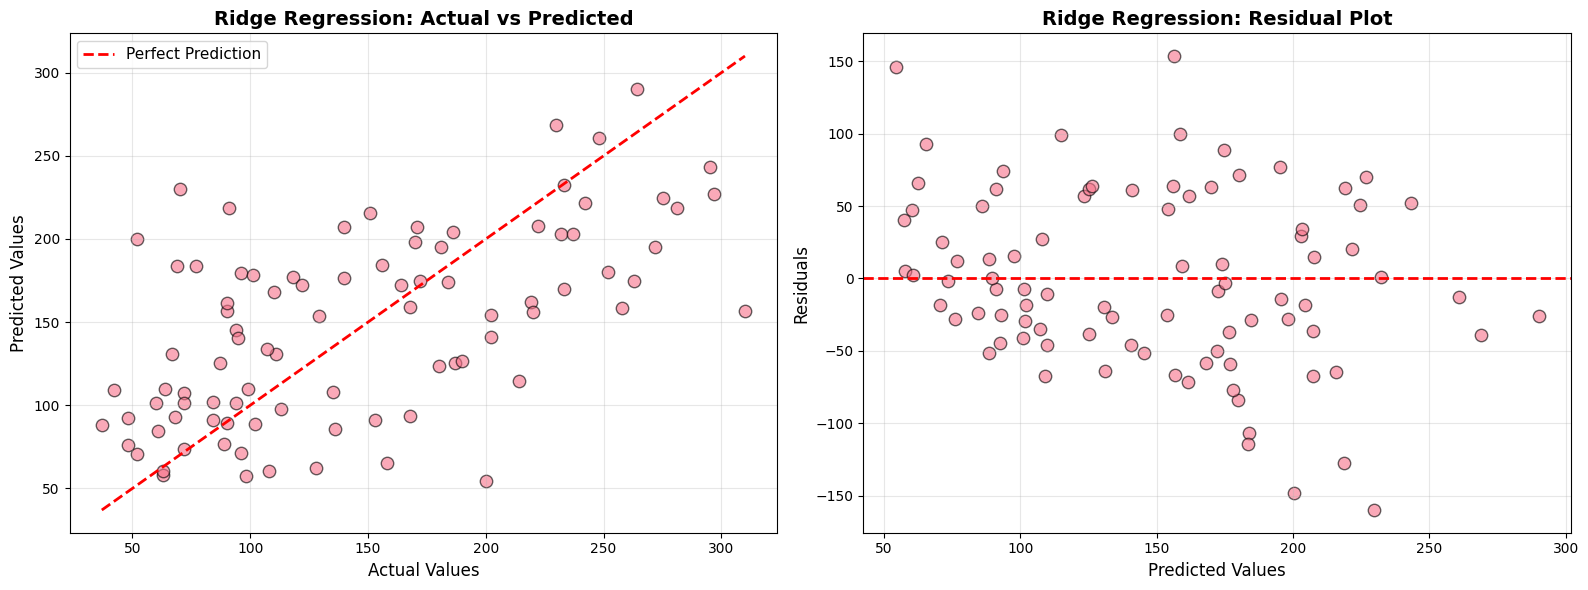

✅ Best model predictions saved as 'best_model_predictions.png'


In [24]:
# Visualize predictions of best model
if best_model_idx == 0:
    y_pred_best = y_test_pred_rf
elif best_model_idx == 1:
    y_pred_best = y_test_pred_gb
else:
    y_pred_best = y_test_pred_ridge

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Actual vs Predicted
axes[0].scatter(y_test, y_pred_best, alpha=0.6, s=80, edgecolors='black')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Values', fontsize=12)
axes[0].set_ylabel('Predicted Values', fontsize=12)
axes[0].set_title(f'{best_model_name}: Actual vs Predicted', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Residuals
residuals = y_test - y_pred_best
axes[1].scatter(y_pred_best, residuals, alpha=0.6, s=80, edgecolors='black')
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Values', fontsize=12)
axes[1].set_ylabel('Residuals', fontsize=12)
axes[1].set_title(f'{best_model_name}: Residual Plot', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('best_model_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Best model predictions saved as 'best_model_predictions.png'")

## Step 12: Save Model and Preprocessing Objects

In [26]:
# Create model directory
import os
os.makedirs('model', exist_ok=True)

# Save the best model
model_path = 'model/best_model.pkl'
joblib.dump(best_model, model_path)

# Save the scaler
scaler_path = 'model/scaler.pkl'
joblib.dump(scaler, scaler_path)

# Save feature names
feature_names = list(X_train_final.columns)
with open('model/feature_names.json', 'w') as f:
    json.dump(feature_names, f)

# Save model metadata
metadata = {
    'model_name': best_model_name,
    'test_r2': float(results_df.loc[best_model_idx, 'Test R²']),
    'test_rmse': float(results_df.loc[best_model_idx, 'Test RMSE']),
    'test_mae': float(results_df.loc[best_model_idx, 'Test MAE']),
    'cv_score': float(results_df.loc[best_model_idx, 'CV R² Mean']),
    'n_features': len(feature_names),
    'feature_names': feature_names
}

with open('model/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"✅ Best model saved to {model_path}")
print(f"✅ Scaler saved to {scaler_path}")
print(f"✅ Metadata saved to model/metadata.json")

✅ Best model saved to model/best_model.pkl
✅ Scaler saved to model/scaler.pkl
✅ Metadata saved to model/metadata.json


## Step 13: Connect to Azure ML Workspace

In [27]:
# Option 1: Connect using config file (recommended)
# If you have a config.json file from Azure ML Studio, use this:
try:
    ws = Workspace.from_config()
    print(f"✅ Connected to workspace: {ws.name}")
    print(f"   Subscription ID: {ws.subscription_id}")
    print(f"   Resource Group: {ws.resource_group}")
    print(f"   Location: {ws.location}")
except:
    print("❌ Config file not found. Please use Option 2 below.")
    ws = None

Performing interactive authentication. Please follow the instructions on the terminal.


The default web browser has been opened at https://login.microsoftonline.com/organizations/oauth2/v2.0/authorize. Please continue the login in the web browser. If no web browser is available or if the web browser fails to open, use device code flow with `az login --use-device-code`.


❌ Config file not found. Please use Option 2 below.


In [ ]:
# Option 2: Connect manually (use this if config file doesn't exist)
# Uncomment and fill in your details:

# subscription_id = 'YOUR_SUBSCRIPTION_ID'
# resource_group = 'YOUR_RESOURCE_GROUP'
# workspace_name = 'YOUR_WORKSPACE_NAME'

# ws = Workspace(subscription_id=subscription_id,
#                resource_group=resource_group,
#                workspace_name=workspace_name)

# print(f"✅ Connected to workspace: {ws.name}")

## Step 14: Create Enhanced Scoring Script

This script handles preprocessing and prediction using the best model.

In [28]:
%%writefile score.py
import json
import numpy as np
import pandas as pd
import joblib
from azureml.core.model import Model

def init():
    """Initialize the model and preprocessing objects"""
    global model, scaler, feature_names, metadata
    
    # Get model paths
    model_path = Model.get_model_path('best_diabetes_model')
    scaler_path = Model.get_model_path('diabetes_scaler')
    
    # Load model and scaler
    model = joblib.load(model_path)
    scaler = joblib.load(scaler_path)
    
    # Load feature names and metadata
    with open(Model.get_model_path('feature_names'), 'r') as f:
        feature_names = json.load(f)
    
    with open(Model.get_model_path('metadata'), 'r') as f:
        metadata = json.load(f)
    
    print(f"Model loaded successfully: {metadata['model_name']}")
    print(f"Test R²: {metadata['test_r2']:.4f}")

def preprocess_features(data_df):
    """Preprocess input features"""
    # Scale original features
    original_features = ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
    data_scaled = pd.DataFrame(
        scaler.transform(data_df[original_features]),
        columns=original_features,
        index=data_df.index
    )
    
    # Add engineered features if they exist in feature_names
    if any('squared' in f for f in feature_names):
        # Add squared features for top correlated features
        # Note: This should match the feature engineering in training
        for feat in ['bmi', 's5', 'bp']:  # Adjust based on your top features
            if f'{feat}_squared' in feature_names:
                data_scaled[f'{feat}_squared'] = data_scaled[feat] ** 2
    
    if 'interaction_1' in feature_names:
        # Add interaction terms
        data_scaled['interaction_1'] = data_scaled['bmi'] * data_scaled['s5']
    
    # Ensure all required features are present
    return data_scaled[feature_names]

def run(raw_data):
    """Make predictions on input data"""
    try:
        # Parse input data
        input_data = json.loads(raw_data)
        data = input_data['data']
        
        # Convert to DataFrame
        original_features = ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
        data_df = pd.DataFrame(data, columns=original_features)
        
        # Preprocess
        processed_data = preprocess_features(data_df)
        
        # Make prediction
        predictions = model.predict(processed_data)
        
        # Return results with metadata
        return json.dumps({
            "predictions": predictions.tolist(),
            "model": metadata['model_name'],
            "model_r2": metadata['test_r2']
        })
    except Exception as e:
        error = str(e)
        return json.dumps({"error": error})

Overwriting score.py


## Step 15: Register Models in Azure ML Workspace

In [ ]:
# Register the best model
registered_model = Model.register(
    workspace=ws,
    model_name='best_diabetes_model',
    model_path=model_path,
    description=f'{best_model_name} for diabetes prediction',
    tags={
        'type': 'regression',
        'framework': 'sklearn',
        'model': best_model_name,
        'test_r2': str(results_df.loc[best_model_idx, 'Test R²']),
        'test_rmse': str(results_df.loc[best_model_idx, 'Test RMSE'])
    }
)

print(f"✅ Model registered: {registered_model.name}, Version: {registered_model.version}")

# Register the scaler
scaler_model = Model.register(
    workspace=ws,
    model_name='diabetes_scaler',
    model_path=scaler_path,
    description='StandardScaler for diabetes features'
)

print(f"✅ Scaler registered: {scaler_model.name}, Version: {scaler_model.version}")

# Register feature names
feature_names_model = Model.register(
    workspace=ws,
    model_name='feature_names',
    model_path='model/feature_names.json',
    description='Feature names for diabetes model'
)

print(f"✅ Feature names registered: {feature_names_model.name}, Version: {feature_names_model.version}")

# Register metadata
metadata_model = Model.register(
    workspace=ws,
    model_name='metadata',
    model_path='model/metadata.json',
    description='Metadata for diabetes model'
)

print(f"✅ Metadata registered: {metadata_model.name}, Version: {metadata_model.version}")

## Step 16: Create Environment Configuration

In [ ]:
# Create environment
env = Environment(name='diabetes-enhanced-env')

# Specify conda dependencies
conda_dep = CondaDependencies()
conda_dep.add_pip_package('azureml-defaults')
conda_dep.add_pip_package('scikit-learn==1.3.0')
conda_dep.add_pip_package('joblib')
conda_dep.add_pip_package('numpy')
conda_dep.add_pip_package('pandas')

env.python.conda_dependencies = conda_dep

print("✅ Environment configuration created")

## Step 17: Configure Inference

In [ ]:
# Create inference configuration
inference_config = InferenceConfig(
    entry_script='score.py',
    environment=env
)

print("✅ Inference configuration created")

## Step 18: Configure Azure Container Instance (ACI) Deployment

In [ ]:
# Configure ACI deployment
aci_config = AciWebservice.deploy_configuration(
    cpu_cores=1,
    memory_gb=2,  # Increased memory for preprocessing
    auth_enabled=True,
    description=f'{best_model_name} diabetes prediction deployment',
    tags={
        'model': best_model_name,
        'framework': 'sklearn',
        'test_r2': str(results_df.loc[best_model_idx, 'Test R²'])
    }
)

print("✅ ACI deployment configuration created")

## Step 19: Deploy Best Model to Azure Container Instance

⚠️ **This step may take 5-10 minutes to complete.**

In [ ]:
# Deploy the model
service_name = 'diabetes-best-service'

# Check if service already exists and delete it
try:
    existing_service = Webservice(workspace=ws, name=service_name)
    print(f"Service {service_name} already exists. Deleting it...")
    existing_service.delete()
    print("Existing service deleted.")
except:
    print(f"No existing service named {service_name}. Proceeding with deployment.")

# Deploy new service
print("\nStarting deployment... This may take several minutes.")
print(f"Deploying {best_model_name}...")

service = Model.deploy(
    workspace=ws,
    name=service_name,
    models=[registered_model, scaler_model, feature_names_model, metadata_model],
    inference_config=inference_config,
    deployment_config=aci_config,
    overwrite=True
)

service.wait_for_deployment(show_output=True)
print(f"\n✅ Deployment complete!")
print(f"Service state: {service.state}")
print(f"Scoring URI: {service.scoring_uri}")

## Step 20: Get Service Details and Authentication Key

In [ ]:
# Get authentication keys
primary_key, secondary_key = service.get_keys()

print("\n" + "="*80)
print("🎉 DEPLOYMENT SUCCESSFUL")
print("="*80)
print(f"\nBest Model Deployed: {best_model_name}")
print(f"Test R² Score: {results_df.loc[best_model_idx, 'Test R²']:.4f}")
print(f"Test RMSE: {results_df.loc[best_model_idx, 'Test RMSE']:.4f}")
print("\n" + "-"*80)
print("SERVICE DETAILS")
print("-"*80)
print(f"Service Name: {service.name}")
print(f"Scoring URI: {service.scoring_uri}")
print(f"\nPrimary Key: {primary_key}")
print(f"Secondary Key: {secondary_key}")
print("="*80)
print("\n⚠️  IMPORTANT: Save these keys securely!")
print("="*80)

## Step 21: Test the Deployed Service

In [ ]:
import requests

# Prepare test data (using first few rows from test set)
# Note: We only need the original 10 features, preprocessing happens in the scoring script
original_features = ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
test_samples = X_test[original_features].iloc[0:3].values.tolist()
actual_values = y_test.iloc[0:3].values

# Create input data
input_data = json.dumps({
    'data': test_samples
})

# Set headers with authentication
headers = {
    'Content-Type': 'application/json',
    'Authorization': f'Bearer {primary_key}'
}

# Make prediction request
print("Sending test request to deployed service...\n")
response = requests.post(service.scoring_uri, data=input_data, headers=headers)

# Display results
result = response.json()
predictions = result['predictions']

print("="*80)
print("TEST RESULTS")
print("="*80)
print(f"Model Used: {result.get('model', 'N/A')}")
print(f"Model R²: {result.get('model_r2', 'N/A')}")
print("\nPrediction Results:")
print("-"*80)
for i, (actual, pred) in enumerate(zip(actual_values, predictions), 1):
    error = abs(actual - pred)
    print(f"Sample {i}:")
    print(f"  Actual: {actual:.2f}")
    print(f"  Predicted: {pred:.2f}")
    print(f"  Error: {error:.2f}")
    print()
print("="*80)

## Step 22: Example Code for Production Use

In [ ]:
# Generate example code for production
example_code = f'''
import requests
import json

# ============================================================================
# Azure ML Diabetes Prediction Service - Production Code
# ============================================================================
# Model: {best_model_name}
# Test R²: {results_df.loc[best_model_idx, 'Test R²']:.4f}
# Test RMSE: {results_df.loc[best_model_idx, 'Test RMSE']:.4f}
# ============================================================================

# Service configuration
SCORING_URI = "{service.scoring_uri}"
API_KEY = "{primary_key}"  # Use your primary or secondary key

def predict_diabetes_progression(patient_data):
    """
    Make predictions using the deployed Azure ML service.
    
    Parameters:
    -----------
    patient_data : list of lists
        Each inner list should contain 10 features in order:
        [age, sex, bmi, bp, s1, s2, s3, s4, s5, s6]
    
    Returns:
    --------
    dict : Prediction results including predictions and model info
    """
    # Prepare input
    input_data = {{
        'data': patient_data
    }}
    
    # Set headers
    headers = {{
        'Content-Type': 'application/json',
        'Authorization': f'Bearer {{API_KEY}}'
    }}
    
    # Make request
    response = requests.post(
        SCORING_URI,
        data=json.dumps(input_data),
        headers=headers
    )
    
    # Handle response
    if response.status_code == 200:
        return response.json()
    else:
        raise Exception(f"Prediction failed: {{response.status_code}} - {{response.text}}")

# Example usage
if __name__ == "__main__":
    # Example patient data (standardized features)
    # Features: age, sex, bmi, bp, s1, s2, s3, s4, s5, s6
    example_patients = [
        [0.038, 0.051, 0.062, 0.022, -0.044, -0.035, -0.043, -0.003, 0.020, -0.018],
        [-0.001, -0.045, -0.051, -0.026, -0.008, -0.019, 0.074, -0.039, -0.068, -0.092]
    ]
    
    # Make predictions
    try:
        result = predict_diabetes_progression(example_patients)
        print("Predictions:", result['predictions'])
        print("Model:", result['model'])
        print("Model R²:", result['model_r2'])
    except Exception as e:
        print(f"Error: {{e}}")
'''

# Save example code to file
with open('production_example.py', 'w') as f:
    f.write(example_code)

print("\n" + "="*80)
print("PRODUCTION CODE")
print("="*80)
print(example_code)
print("\n✅ Production example code saved to 'production_example.py'")

## Step 23: Model Monitoring and Logs

In [ ]:
# Get service logs (useful for debugging)
logs = service.get_logs()
print("Service Logs (last 2000 characters):")
print("="*80)
print(logs[-2000:])
print("="*80)

## Step 24: Generate Final Summary Report

In [ ]:
# Create comprehensive summary
summary_report = f"""
{'='*80}
DIABETES PREDICTION MODEL - DEPLOYMENT SUMMARY REPORT
{'='*80}

PROJECT OVERVIEW:
{'-'*80}
Dataset: Diabetes Dataset (sklearn)
Total Samples: {len(X)}
Features: {X.shape[1]} original + {X_train_enhanced.shape[1] - X.shape[1]} engineered = {X_train_enhanced.shape[1]} total
Target: Disease Progression (quantitative measure)

DATA PROCESSING:
{'-'*80}
1. Exploratory Data Analysis ✅
2. Feature Standardization (StandardScaler) ✅
3. Feature Engineering (polynomial & interaction features) ✅
4. PCA Analysis (95% variance retained in {n_components_95} components) ✅

MODELS EVALUATED:
{'-'*80}
{results_df.to_string(index=False)}

BEST MODEL SELECTED:
{'-'*80}
Model: {best_model_name}
Test R² Score: {results_df.loc[best_model_idx, 'Test R²']:.4f}
Test RMSE: {results_df.loc[best_model_idx, 'Test RMSE']:.4f}
Test MAE: {results_df.loc[best_model_idx, 'Test MAE']:.4f}
CV R² Score: {results_df.loc[best_model_idx, 'CV R² Mean']:.4f} (+/- {results_df.loc[best_model_idx, 'CV R² Std']:.4f})
Training Time: {results_df.loc[best_model_idx, 'Train Time (s)']:.3f}s

DEPLOYMENT DETAILS:
{'-'*80}
Platform: Azure Container Instance (ACI)
Service Name: {service.name}
Scoring URI: {service.scoring_uri}
Status: {service.state}
CPU Cores: 1
Memory: 2 GB
Authentication: Key-based (enabled)

REGISTERED ARTIFACTS:
{'-'*80}
1. Best Model: {registered_model.name} (v{registered_model.version})
2. Scaler: {scaler_model.name} (v{scaler_model.version})
3. Feature Names: {feature_names_model.name} (v{feature_names_model.version})
4. Metadata: {metadata_model.name} (v{metadata_model.version})

GENERATED VISUALIZATIONS:
{'-'*80}
1. eda_visualizations.png - Comprehensive EDA plots
2. correlation_matrix.png - Feature correlation heatmap
3. pairplot.png - Pairplot of top correlated features
4. pca_analysis.png - PCA variance analysis
5. pca_2d_projection.png - 2D PCA projection
6. model_comparison.png - Model performance comparison
7. best_model_predictions.png - Prediction vs actual plots
8. feature_importance.png - Feature importance (if applicable)

FILES CREATED:
{'-'*80}
1. score.py - Inference script
2. production_example.py - Production usage example
3. model/best_model.pkl - Trained model
4. model/scaler.pkl - Feature scaler
5. model/feature_names.json - Feature configuration
6. model/metadata.json - Model metadata

NEXT STEPS:
{'-'*80}
1. Test the API with your own data
2. Integrate into your application using production_example.py
3. Monitor model performance in Azure ML Studio
4. Set up logging and alerting
5. Consider A/B testing with alternative models
6. Schedule periodic retraining with new data

IMPORTANT NOTES:
{'-'*80}
⚠️  Remember to delete the ACI service when not in use to avoid charges
⚠️  Store your API keys securely - never commit them to version control
⚠️  Monitor your service usage and costs in Azure Portal
⚠️  For production workloads, consider deploying to AKS instead of ACI

{'='*80}
Report Generated: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}
{'='*80}
"""

print(summary_report)

# Save report
with open('deployment_summary_report.txt', 'w') as f:
    f.write(summary_report)

print("\n✅ Summary report saved to 'deployment_summary_report.txt'")

## Optional: Clean Up Resources

**⚠️ Warning:** Run this cell only when you want to delete the deployment to avoid Azure charges.

In [ ]:
# Uncomment to delete the service
# service.delete()
# print("✅ Service deleted successfully")
# print("\nTo redeploy, simply run the deployment cells again.")